# LAB 1 for CS4243: Textures and Materials
## Notebook 4 — Personal photos and controlled VLM defect analysis

> **Introduction.** This final notebook combines two open-ended studies. Part I
> develops Texture Passports for your own photographs. Part II evaluates a VLM
> such as ChatGPT on five held-out MVTec defects under three controlled levels
> of information. Preserve inputs, prompts, outputs, and limitations.


# Part I — Personal-photo investigation

## Before looking at predictions

Complete `personal_annotations.csv` first. Obtain two independent selections
of three to five DTD terms per photograph, remove EXIF metadata, and check that
no people, identifying documents, or precise locations are visible.


## Suggested investigation structure

1. Introduce the collection with all relevant information.
2. Apply the frozen material, defect, and DTD systems without adapting them to this new data.
3. Select revealing successes, failures, and intermediate response maps.
4. Test one focused question about illumination, scale, or viewpoint.
5. Produce one Texture Passport per image and explain/reason about the uncertainty.


In [1]:
import sys
from pathlib import Path

import joblib

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
PERSONAL_MANIFEST = ROOT / "manifests" / "personal_annotations.csv"
MODEL_DIR = ROOT / "outputs" / "models"

print("manifest available:", PERSONAL_MANIFEST.exists())
print("model directory available:", MODEL_DIR.exists())

# Notebooks 2 and 3 save self-describing bundles here. Load whichever are
# available, while keeping this open-ended notebook usable before training.
task_ab_path = MODEL_DIR / "task_ab_models.joblib"
task_c_path = MODEL_DIR / "task_c_attribute_model.joblib"
task_ab_bundle = joblib.load(task_ab_path) if task_ab_path.exists() else None
task_c_bundle = joblib.load(task_c_path) if task_c_path.exists() else None

if task_ab_bundle is None or task_c_bundle is None:
    print("Run Notebooks 2 and 3 first to create any missing model bundles.")
else:
    material_model = task_ab_bundle["material_classifier"]
    normal_models = task_ab_bundle["normal_models"]
    attribute_model = task_c_bundle["attribute_classifier"]
    feature_config = task_ab_bundle["feature_config"]
    normality_config = task_ab_bundle["normality_config"]
    attribute_config = task_c_bundle["feature_config"]
    attributes = task_c_bundle["attributes"]
    print("Loaded Task A/B keys:", sorted(task_ab_bundle))
    print("Loaded Task C keys:", sorted(task_c_bundle))

manifest available: False
model directory available: True
Loaded Task A/B keys: ['feature_config', 'image_size', 'material_classifier', 'materials', 'normal_models', 'normality_config', 'validation_selected_threshold']
Loaded Task C keys: ['attribute_classifier', 'attributes', 'feature_config', 'image_size']


## Personal-photo analysis workspace

When Notebooks 2 and 3 have been run, the setup cell exposes `material_model`, `normal_models`, `attribute_model`, their exact feature configurations, the attribute order, and the complete model bundles. Use these frozen objects without refitting on personal images.

Add your own loading, inference, and plotting cells here. Useful visualisations
include a contact sheet grouped by acquisition condition, image/heatmap/mask
triptychs, material confidence versus anomaly score, and human--model DTD-term
overlap. Every figure should support a stated claim.


Photo: grid_round_close.jpeg
Material: grid (0.97)
Top attributes: grid 0.35, braided 0.22, pitted 0.11, porous 0.10, cracked 0.08
Anomaly image score: 1.52


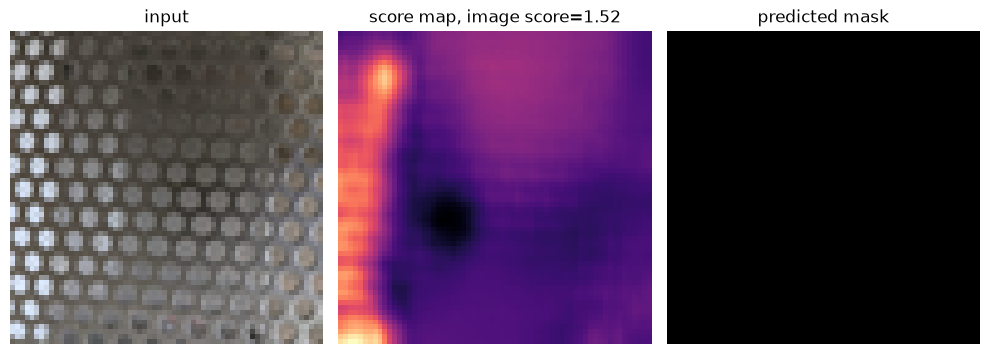

In [2]:
# [AI-CODE][HUMAN-CHECK]
# Simple first test of the frozen pipeline on one personal photo.
import matplotlib.pyplot as plt
import numpy as np

from texturelab.features import extract_local_features, global_pool
from texturelab.normality import predict_anomaly
from texturelab.supplied import load_image

PHOTO_DIR = ROOT / "student_files" / "personnal_photos_clean"
photo_path = sorted(PHOTO_DIR.glob("*.jpeg"))[1]

# Same image size as the training data (64x64), so the features match.
image = load_image(str(photo_path), task_ab_bundle["image_size"])

# Task A: material
fmap, _ = extract_local_features(image, feature_config)
material_proba = material_model.predict_proba(global_pool(fmap)[None])[0]
material = material_model.classes_[material_proba.argmax()]

# Task C: top 5 DTD attributes
attr_fmap, _ = extract_local_features(image, attribute_config)
attr_proba = attribute_model.predict_proba(global_pool(attr_fmap)[None])[0]
top5 = np.argsort(attr_proba)[::-1][:5]

# Task B: anomaly map with the normal model of the predicted material
score_map, image_score, mask = predict_anomaly(fmap, normal_models[material], normality_config)

print(f"Photo: {photo_path.name}")
print(f"Material: {material} ({material_proba.max():.2f})")
print("Top attributes:", ", ".join(f"{attributes[i]} {attr_proba[i]:.2f}" for i in top5))
print(f"Anomaly image score: {image_score:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
axes[0].imshow(image)
axes[0].set_title("input")
axes[1].imshow(score_map, cmap="magma")
axes[1].set_title(f"score map, image score={image_score:.2f}")
axes[2].imshow(mask, cmap="gray")
axes[2].set_title("predicted mask")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
plt.show()

In [3]:
# Hand-written passport text, one entry per photo [AI-LANGUAGE] [HUMAN-DATA] [HUMAN-CHECK].
# Look at the photo and its passport figure (input, score map, mask) before writing.
# Keep the description evidence-grounded (what is visible + what the maps show)
# and the uncertainty about what could make the outputs wrong. Clearly wrong
# materials or missed/false defects are stated, as a human inspector would.
PASSPORT_TEXT = {
    # photo: student_files/personnal_photos_clean/grid_chair.jpeg   figure: student_files/report/passports/grid_chair.png
    "grid_chair.jpeg": {
        "description": "A woven cane grid of light holes on a brown background, with no visible defect. The score map is high almost everywhere, and over half of the image is flagged.",
        "uncertainty": "The material is clearly wrong: this is a grid, not wood. The wood normal model is therefore applied, so the very high score (52.46) and the mask are artefacts of the wrong model, not defects.",
    },
    # photo: student_files/personnal_photos_clean/grid_round_close.jpeg   figure: student_files/report/passports/grid_round_close.png
    "grid_round_close.jpeg": {
        "description": "A regular perforated metal sheet with round holes and no visible defect. The score map stays low, with a mild response on the left edge, and nothing is flagged.",
        "uncertainty": "The material and the absence of a defect are both correct. The left-edge response follows the uneven background seen through the holes, and the attribute scores are low (grid 0.35 at best).",
    },
    # photo: student_files/personnal_photos_clean/grid_round_far.jpeg   figure: student_files/report/passports/grid_round_far.png
    "grid_round_far.jpeg": {
        "description": "The same perforated sheet seen obliquely and from further away, with a bend in the sheet and no visible defect. The strongest responses follow the bottom and the bend.",
        "uncertainty": "The material is clearly wrong: at this scale the holes look like streaks and the sheet is read as wood. The flagged regions come from the wrong normal model and the bend, so they are false positives.",
    },
    # photo: student_files/personnal_photos_clean/grid_square.jpeg   figure: student_files/report/passports/grid_square.png
    "grid_square.jpeg": {
        "description": "A perforated sheet with regular square holes, seen slightly in perspective, with no visible defect. The score map has a moderate response near the top, and nothing is flagged.",
        "uncertainty": "The material is clearly wrong: the regular square holes form a grid, yet the model is fully confident in tile (1.00). No defect is correct, but it is judged against the tile normal model.",
    },
    # photo: student_files/personnal_photos_clean/tile_black.jpeg   figure: student_files/report/passports/tile_black.png
    "tile_black.jpeg": {
        "description": "A dark, finely speckled tile with small bright grains and no visible defect. The score map is elevated on the left, and a small region at the bottom-left is flagged.",
        "uncertainty": "The material is clearly wrong: this is a tile, not carpet, as the fine grains at 64x64 resemble fibres. The flagged region follows brighter lighting on the left and is a false positive.",
    },
    # photo: student_files/personnal_photos_clean/tile_colour.jpeg   figure: student_files/report/passports/tile_colour.png
    "tile_colour.jpeg": {
        "description": "A smooth pale tile with a small green colour mark left of centre. The score map peaks at the top-right corner, and a large diagonal band is flagged instead of the mark.",
        "uncertainty": "The material is clearly wrong: a plain tile is predicted as wood. The mask misses the green mark, which is the actual defect, and flags lighting changes on an almost textureless surface.",
    },
    # photo: student_files/personnal_photos_clean/tile_granite.jpeg   figure: student_files/report/passports/tile_granite.png
    "tile_granite.jpeg": {
        "description": "A grey granite-like tile seen frontally, with fine dark and light speckles and no visible defect. The score map is high along the left side and a few spots, and about a sixth of the image is flagged there.",
        "uncertainty": "The material is clearly wrong: a tile is predicted as carpet, with low confidence (0.46), because the fine speckles resemble fibres at 64x64. The flagged regions follow the uneven speckle density, not a defect, so they are false positives.",
    },
    # photo: student_files/personnal_photos_clean/tile_granite_tilted.jpeg   figure: student_files/report/passports/tile_granite_tilted.png
    "tile_granite_tilted.jpeg": {
        "description": "The same granite-like tile seen obliquely, so the speckle looks finer and smoother towards the top than at the bottom. The score map is high in the upper-left and low in the lower half, and nothing is flagged.",
        "uncertainty": "The material is correct, but with very low confidence (0.34), so it should not be trusted. The top attributes (grid 0.44, blotchy 0.26) are loosely matched, and the high response at the top reflects the change of apparent scale caused by the viewpoint, not a defect.",
    },
    # photo: student_files/personnal_photos_clean/tile_grid.jpeg   figure: student_files/report/passports/tile_grid.png
    "tile_grid.jpeg": {
        "description": "Pale square tiles separated by faint grout lines, seen from further away, with no visible defect. A few bright blobs in the score map become large flagged regions.",
        "uncertainty": "The material is clearly wrong: the straight grout lines are read as wood grain. The flagged regions are grout intersections and lighting, so they are false positives from the wrong normal model.",
    },
    # photo: student_files/personnal_photos_clean/tile_liquid.jpeg   figure: student_files/report/passports/tile_liquid.png
    "tile_liquid.jpeg": {
        "description": "A light grey stone tile with a darker liquid stain at the bottom centre. The strongest response is on the stain, but large regions in the upper half are also flagged.",
        "uncertainty": "The material is clearly wrong: stone tile is predicted as wood. The stain is correctly highlighted, but the wrong normal model makes the mask far larger than the actual defect.",
    },
    # photo: student_files/personnal_photos_clean/tile_no_colour.jpeg   figure: student_files/report/passports/tile_no_colour.png
    "tile_no_colour.jpeg": {
        "description": "A smooth, nearly uniform pale tile with gradual darkening towards the bottom and no visible defect. About a third of the image, along a band in the lower half, is flagged.",
        "uncertainty": "The material is clearly wrong: a plain tile is predicted as wood with high confidence (0.97). The flagged band follows a shading gradient, so it is a false positive caused by illumination.",
    },
    # photo: student_files/personnal_photos_clean/tile_noliquid.jpeg   figure: student_files/report/passports/tile_noliquid.png
    "tile_noliquid.jpeg": {
        "description": "A granular stone tile with yellowish and grey mottling and no visible defect. The score map is high in the upper-left, but only a very small region there is flagged.",
        "uncertainty": "The material is clearly wrong: the stone tile is predicted as carpet, with low confidence (0.50). The small flagged region follows a change in colour and is not a defect.",
    },
    # photo: student_files/personnal_photos_clean/tile_white_defect.jpeg   figure: student_files/report/passports/tile_white_defect.png
    "tile_white_defect.jpeg": {
        "description": "A speckled beige tile with large dark holes in the upper half. The score map shows a clear peak on the left hole, but it stays below the threshold, so nothing is flagged.",
        "uncertainty": "The material is correct, but with low confidence (0.55). The holes are clearly defects and are missed: the score map sees them, but the frozen threshold is too high for this photo.",
    },
    # photo: student_files/personnal_photos_clean/tile_white_hole.jpeg   figure: student_files/report/passports/tile_white_hole.png
    "tile_white_hole.jpeg": {
        "description": "A speckled beige tile with a dark hole at the centre and a bright specular reflection to its right. The score map has two peaks, on the hole and on the reflection.",
        "uncertainty": "The material is clearly wrong: a tile is predicted as wood, which inflates the score (40.87). The hole is a real defect, but the reflection is flagged just as strongly and is a false positive.",
    },
    # photo: student_files/personnal_photos_clean/wood.jpeg   figure: student_files/report/passports/wood.png
    "wood.jpeg": {
        "description": "Pale wood with vertical grain, a slightly darker streak on the right, and no visible defect. The score map is moderate along the grain, and a few small spots are flagged.",
        "uncertainty": "The material is correct with high confidence (1.00). The few flagged spots do not match any visible defect, so they are false positives from natural grain variation.",
    },
    # photo: student_files/personnal_photos_clean/wood_bad_light.jpeg   figure: student_files/report/passports/wood_bad_light.png
    "wood_bad_light.jpeg": {
        "description": "Wood grain with a strong lighting change: the left is brightly lit and the right is in shadow. The score map peaks along the boundary between the two, but nothing is flagged.",
        "uncertainty": "The material is clearly wrong: this is wood, predicted as tile. The shadow boundary creates an artificial edge, which drives the high banded (0.87) and stained (0.74) scores.",
    },
    # photo: student_files/personnal_photos_clean/wood_pale.jpeg   figure: student_files/report/passports/wood_pale.png
    "wood_pale.jpeg": {
        "description": "Pale wood with faint vertical grain and no visible defect. The score map peaks at the left edge, and a few small regions, mainly near the top, are flagged.",
        "uncertainty": "The material is correct with high confidence (0.99). The flagged regions are small and match no visible defect, so they are false positives from grain variation or lighting.",
    },
    
}

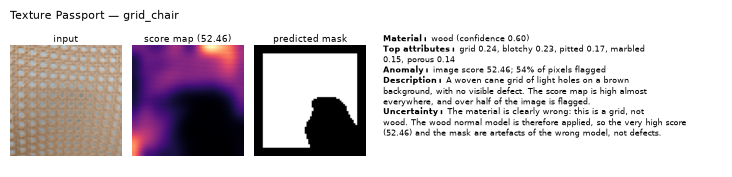

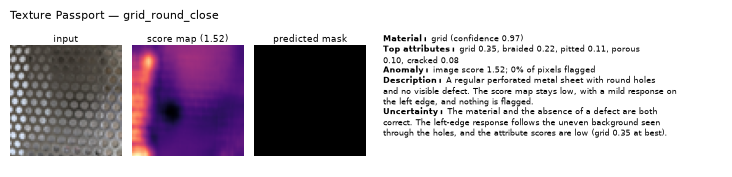

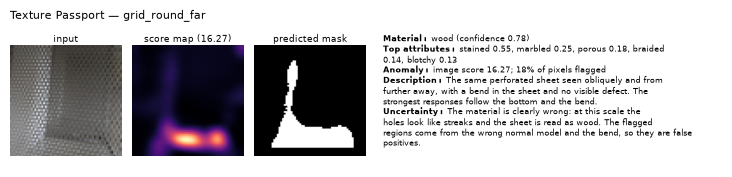

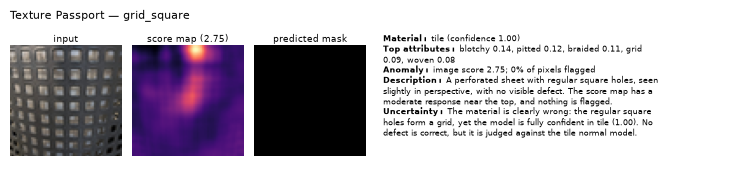

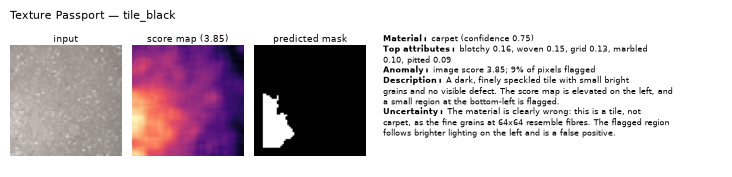

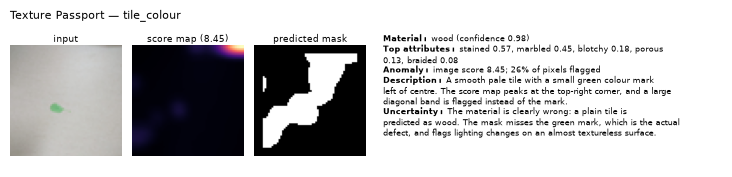

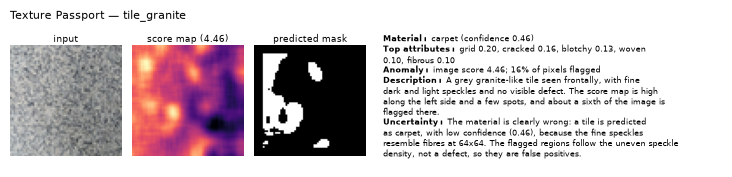

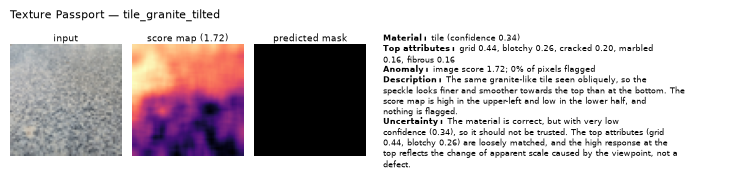

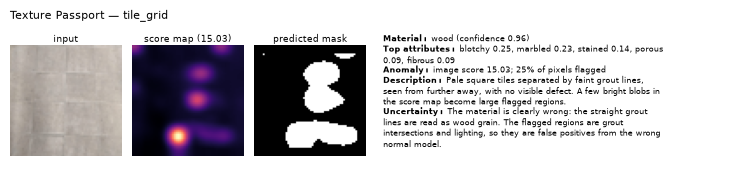

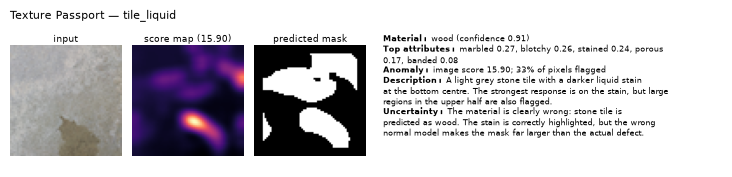

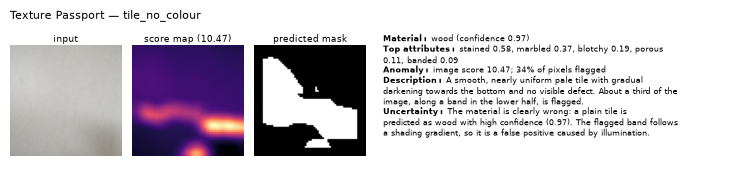

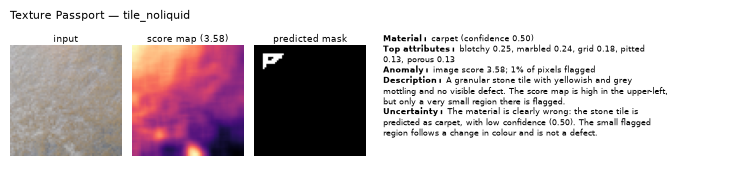

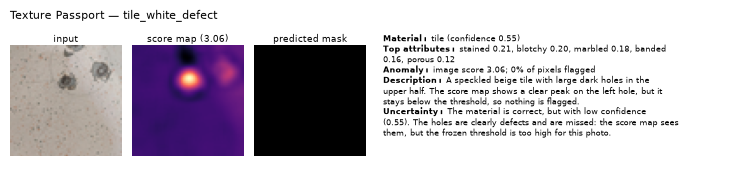

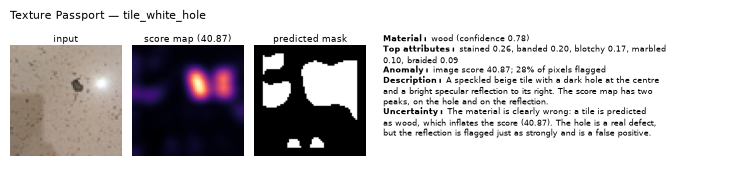

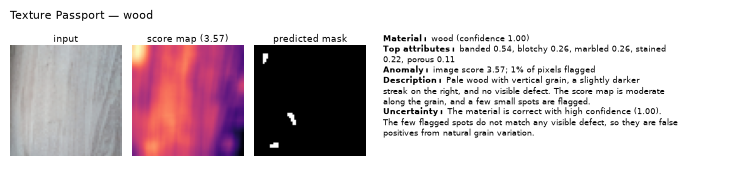

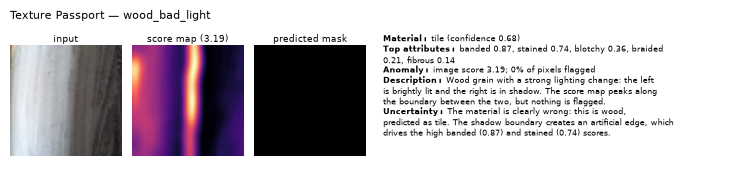

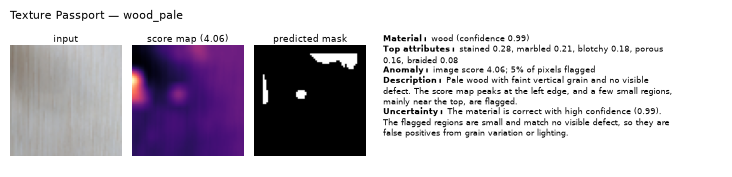

grid_chair.jpeg         wood    0.60  score  52.46  flagged  54%  (annotated grid, good)
grid_round_close.jpeg   grid    0.97  score   1.52  flagged   0%  (annotated grid, good)
grid_round_far.jpeg     wood    0.78  score  16.27  flagged  18%  (annotated grid, good)
grid_square.jpeg        tile    1.00  score   2.75  flagged   0%  (annotated grid, good)
tile_black.jpeg         carpet  0.75  score   3.85  flagged   9%  (annotated tile, good)
tile_colour.jpeg        wood    0.98  score   8.45  flagged  26%  (annotated tile, colour)
tile_granite.jpeg       carpet  0.46  score   4.46  flagged  16%  (annotated tile, good)
tile_granite_tilted.jpegtile    0.34  score   1.72  flagged   0%  (annotated tile, good)
tile_grid.jpeg          wood    0.96  score  15.03  flagged  25%  (annotated tile, good)
tile_liquid.jpeg        wood    0.91  score  15.90  flagged  33%  (annotated tile, liquid)
tile_no_colour.jpeg     wood    0.97  score  10.47  flagged  34%  (annotated tile, good)
tile_noliquid.jpe

In [4]:
# [AI-CODE][HUMAN-CHECK]
# Texture Passport for every personal photo, using the frozen Task A/B/C models only.
import csv
import textwrap

ANNOTATIONS = ROOT / "student_files" / "personnal_annotations.csv"
STUDENT_DIR = ROOT / "student_files"
PASSPORT_DIR = STUDENT_DIR / "report" / "passports"
PASSPORT_DIR.mkdir(parents=True, exist_ok=True)

with ANNOTATIONS.open(newline="", encoding="utf8") as handle:
    annotation_rows = list(csv.DictReader(handle))

threshold = task_ab_bundle["validation_selected_threshold"]


def make_passport(row):
    path = STUDENT_DIR / row["path"]
    image = load_image(str(path), task_ab_bundle["image_size"])

    # Task A: material
    fmap, _ = extract_local_features(image, feature_config)
    material_proba = material_model.predict_proba(global_pool(fmap)[None])[0]
    material = str(material_model.classes_[material_proba.argmax()])
    confidence = float(material_proba.max())

    # Task C: five ranked DTD attributes
    attr_fmap, _ = extract_local_features(image, attribute_config)
    attr_proba = attribute_model.predict_proba(global_pool(attr_fmap)[None])[0]
    top5 = [(attributes[i], float(attr_proba[i])) for i in np.argsort(attr_proba)[::-1][:5]]

    # Task B: anomaly map with the normal model of the predicted material
    score_map, image_score, mask = predict_anomaly(fmap, normal_models[material], normality_config)
    flagged = float(mask.mean())

    # Description and uncertainty are written by hand in PASSPORT_TEXT (cell above).
    text = PASSPORT_TEXT[path.name]
    description, limitation = text["description"], text["uncertainty"]

    return {
        "photo": path.name, "image": image, "annotated_material": row["material"],
        "annotated_defect": row["defect_type"], "human_terms": row["annotator_1_terms"],
        "material": material, "confidence": confidence, "top5": top5,
        "image_score": image_score, "flagged": flagged, "score_map": score_map, "mask": mask,
        "description": description, "limitation": limitation,
        "viewpoint": row["viewpoint"], "scale": row["scale"], "illumination": row["illumination"],
    }


def plot_passport(p):
    # Compact strip (input, score map, mask | text) so it stays legible at page width.
    fig = plt.figure(figsize=(7.2, 1.62))
    grid = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 3.1], wspace=0.06,
                            left=0.005, right=0.995, top=0.84, bottom=0.02)
    panels = [(p["image"], None, "input"),
              (p["score_map"], "magma", f"score map ({p['image_score']:.2f})"),
              (p["mask"], "gray", "predicted mask")]
    for k, (img, cmap, title) in enumerate(panels):
        ax = fig.add_subplot(grid[0, k])
        ax.imshow(img, cmap=cmap, **({"vmin": 0, "vmax": 1} if title == "predicted mask" else {}))
        ax.set_title(title, fontsize=6.5, pad=2)
        ax.axis("off")
    # Model outputs only: no annotations or ground truth in the passport itself.
    wrap = lambda label, body: textwrap.fill(f"$\\bf{{{label}}}$ {body}", width=72)
    text = "\n".join([
        wrap("Material:", f"{p['material']} (confidence {p['confidence']:.2f})"),
        wrap("Top\\ attributes:", ", ".join(f"{name} {score:.2f}" for name, score in p["top5"])),
        wrap("Anomaly:", f"image score {p['image_score']:.2f}; {100 * p['flagged']:.0f}% of pixels flagged"),
        wrap("Description:", p["description"]),
        wrap("Uncertainty:", p["limitation"]),
    ])
    text_ax = fig.add_subplot(grid[0, 3])
    text_ax.axis("off")
    text_ax.text(0.02, 1.0, text, fontsize=6, va="top", linespacing=1.25,
                 transform=text_ax.transAxes)
    fig.suptitle(f"Texture Passport — {Path(p['photo']).stem}", fontsize=8, x=0.005, ha="left", y=0.99)
    fig.savefig(PASSPORT_DIR / f"{Path(p['photo']).stem}.png", dpi=200)
    plt.show()


passports = [make_passport(row) for row in annotation_rows]
for p in passports:
    plot_passport(p)

# Summary table for grouping the photos later. The annotation columns are for
# analysis only and are not part of the passports above.
SUMMARY_FIELDS = ["photo", "annotated_material", "annotated_defect", "material", "confidence",
                  "image_score", "flagged", "viewpoint", "scale", "illumination", "human_terms"]
with (STUDENT_DIR / "passport_summary.csv").open("w", newline="", encoding="utf8") as handle:
    writer = csv.writer(handle)
    writer.writerow(SUMMARY_FIELDS + ["top5"])
    for p in passports:
        writer.writerow([p[k] for k in SUMMARY_FIELDS] +
                        [";".join(f"{n}:{s:.2f}" for n, s in p["top5"])])

for p in passports:
    print(f"{p['photo']:<24}{p['material']:<8}{p['confidence']:.2f}  "
          f"score {p['image_score']:6.2f}  flagged {100 * p['flagged']:3.0f}%  "
          f"(annotated {p['annotated_material']}, {p['annotated_defect']})")

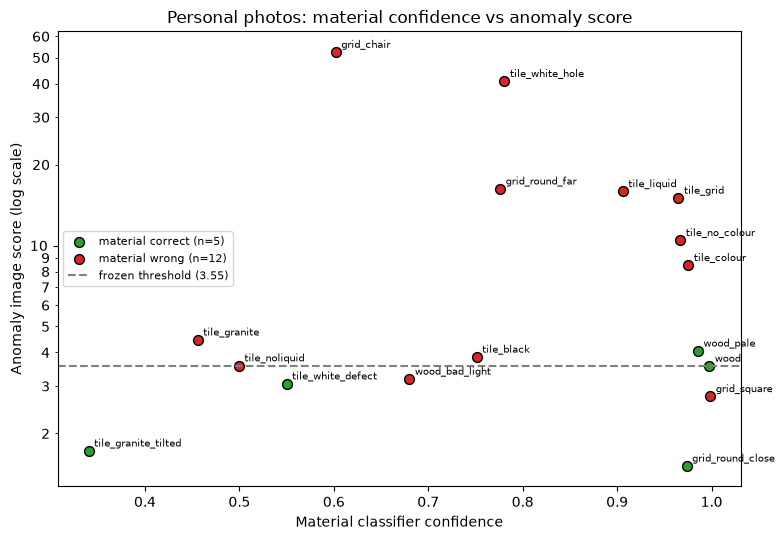

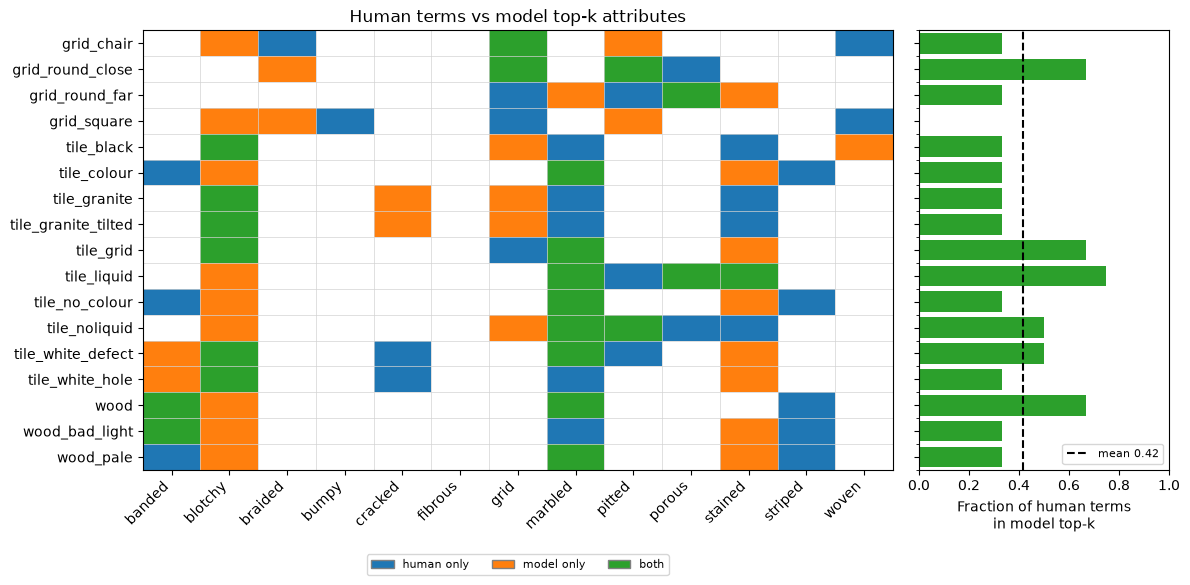

In [5]:
# [AI-CODE]
# Analysis plots for the personal photos. They use the annotations, so they are
# separate from the passports above.
import re

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.ticker import ScalarFormatter

REPORT_DIR = STUDENT_DIR / "report"
threshold = normal_models[passports[0]["material"]].threshold

# 1. Material confidence vs anomaly image score.
fig, ax = plt.subplots(figsize=(8, 5.5))
for correct, colour, label in [(True, "tab:green", "material correct"),
                               (False, "tab:red", "material wrong")]:
    group = [p for p in passports if (p["material"] == p["annotated_material"]) == correct]
    ax.scatter([p["confidence"] for p in group], [p["image_score"] for p in group],
               c=colour, s=50, label=f"{label} (n={len(group)})", edgecolor="k")
for p in passports:
    ax.annotate(Path(p["photo"]).stem, (p["confidence"], p["image_score"]),
                xytext=(4, 3), textcoords="offset points", fontsize=7)
ax.axhline(threshold, ls="--", c="gray", label=f"frozen threshold ({threshold:.2f})")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(ScalarFormatter())
ax.set_xlabel("Material classifier confidence")
ax.set_ylabel("Anomaly image score (log scale)")
ax.set_title("Personal photos: material confidence vs anomaly score")
ax.legend(fontsize=8, loc="center left")
fig.tight_layout()
fig.savefig(REPORT_DIR / "personal_conf_vs_score.png", dpi=150)
plt.show()

# 2. Overlap between human DTD terms and the model's top-k attributes, with k
# equal to the number of human terms for that photo.
with ANNOTATIONS.open(newline="", encoding="utf8") as handle:
    human = {Path(r["path"]).name: [t for t in re.split(r"[;:]", r["annotator_1_terms"]) if t]
             for r in csv.DictReader(handle)}

photos = [p["photo"] for p in passports]
grid = np.zeros((len(photos), len(attributes)), dtype=int)  # 0 none, 1 human, 2 model, 3 both
overlap = []
for i, p in enumerate(passports):
    terms = human[p["photo"]]
    model_terms = [name for name, _ in p["top5"][:len(terms)]]
    for j, attr in enumerate(attributes):
        grid[i, j] = (attr in terms) + 2 * (attr in model_terms)
    overlap.append(len(set(terms) & set(model_terms)) / len(terms))

colours = ["white", "tab:blue", "tab:orange", "tab:green"]
fig, (ax, bx) = plt.subplots(1, 2, figsize=(12, 6), width_ratios=[3, 1], sharey=True)
ax.imshow(grid, cmap=ListedColormap(colours), vmin=0, vmax=3, aspect="auto")
ax.set_xticks(range(len(attributes)), attributes, rotation=45, ha="right")
ax.set_yticks(range(len(photos)), [Path(n).stem for n in photos])
ax.set_xticks(np.arange(-0.5, len(attributes)), minor=True)
ax.set_yticks(np.arange(-0.5, len(photos)), minor=True)
ax.grid(which="minor", c="lightgray", lw=0.5)
ax.tick_params(which="minor", length=0)
ax.legend(handles=[Patch(fc=c, ec="gray", label=l) for c, l in
                   zip(colours[1:], ["human only", "model only", "both"])],
          loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=8)
ax.set_title("Human terms vs model top-k attributes")

bx.barh(range(len(photos)), overlap, color="tab:green")
bx.axvline(np.mean(overlap), ls="--", c="k", label=f"mean {np.mean(overlap):.2f}")
bx.set_xlim(0, 1)
bx.set_xlabel("Fraction of human terms\nin model top-k")
bx.legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(REPORT_DIR / "personal_attribute_overlap.png", dpi=150)
plt.show()

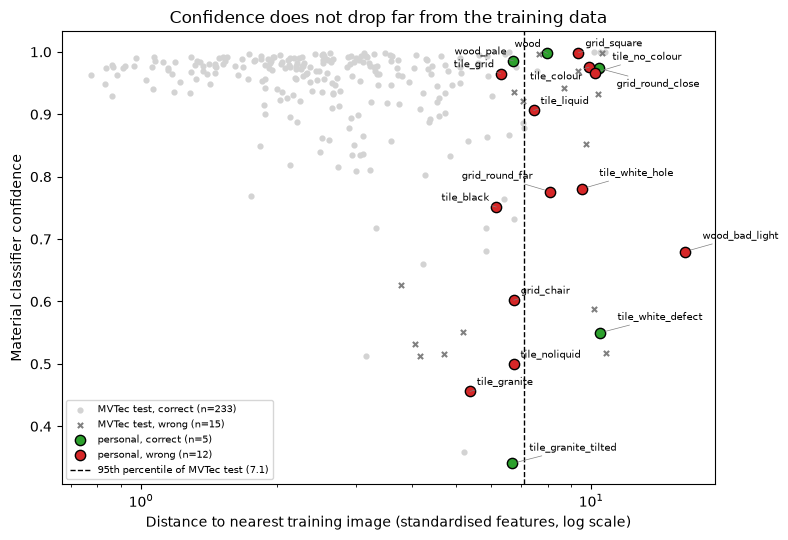

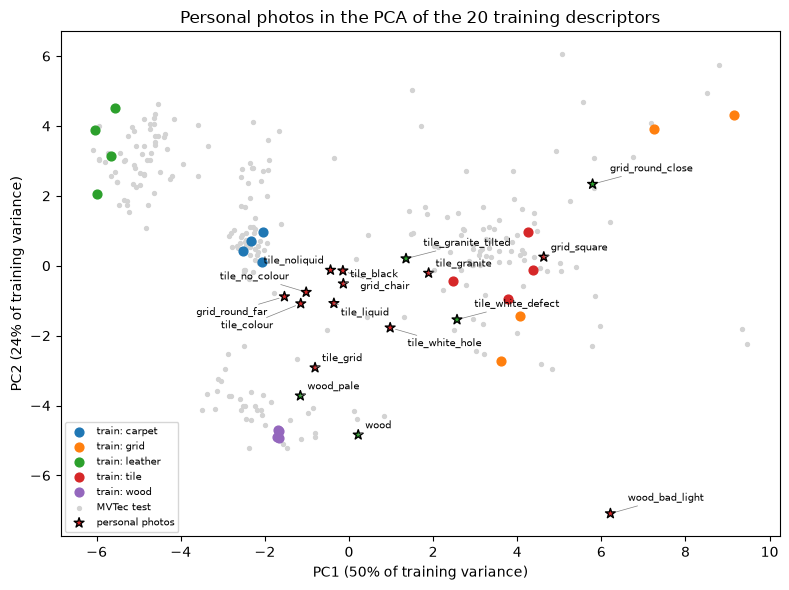

tile_granite.jpeg        distance   5.38  confidence 0.46  carpet
tile_black.jpeg          distance   6.16  confidence 0.75  carpet
tile_grid.jpeg           distance   6.30  confidence 0.96  wood
tile_granite_tilted.jpeg distance   6.67  confidence 0.34  tile
wood_pale.jpeg           distance   6.72  confidence 0.99  wood
tile_noliquid.jpeg       distance   6.72  confidence 0.50  carpet
grid_chair.jpeg          distance   6.73  confidence 0.60  wood
tile_liquid.jpeg         distance   7.45  confidence 0.91  wood
wood.jpeg                distance   7.99  confidence 1.00  wood
grid_round_far.jpeg      distance   8.10  confidence 0.78  wood
grid_square.jpeg         distance   9.37  confidence 1.00  tile
tile_white_hole.jpeg     distance   9.54  confidence 0.78  wood
tile_colour.jpeg         distance   9.89  confidence 0.98  wood
tile_no_colour.jpeg      distance  10.20  confidence 0.97  wood
grid_round_close.jpeg    distance  10.42  confidence 0.97  grid
tile_white_defect.jpeg   distance 

In [6]:
# [AI-CODE]
# Are the personal photos outside the region of feature space the material
# classifier was trained on? Distances are measured in the classifier's own
# standardised space (its StandardScaler), using the exact training set of the
# saved model (first 4 MVTec train images per material). MVTec test images are
# shown as an in-distribution reference.
from sklearn.decomposition import PCA

from texturelab.data import read_manifest

MATERIALS = list(material_model.classes_)
mvtec = read_manifest(ROOT / "manifests" / "mvtec_textures.csv")
train_records = sum(([r for r in mvtec if r.split == "train" and r.material == m][:4]
                     for m in MATERIALS), [])
test_records = [r for r in mvtec if r.split == "test"]
assert len(train_records) == material_model[0].n_samples_seen_


def descriptor(path):
    image = load_image(str(path), task_ab_bundle["image_size"])
    return global_pool(extract_local_features(image, feature_config)[0])


scaler = material_model[0]
z_train = scaler.transform(np.stack([descriptor(r.path) for r in train_records]))
z_test = scaler.transform(np.stack([descriptor(r.path) for r in test_records]))
z_personal = scaler.transform(np.stack([descriptor(STUDENT_DIR / "personnal_photos_clean" / p["photo"])
                                        for p in passports]))


def nearest_train_distance(z):
    return np.linalg.norm(z[:, None] - z_train[None], axis=2).min(axis=1)


def label_points(ax, xs, ys, names, fontsize=7):
    # Greedy label placement: try several sides of each point and keep the first
    # one that overlaps neither an earlier label nor another photo's marker.
    from matplotlib.transforms import Bbox
    ax.figure.canvas.draw()
    renderer = ax.figure.canvas.get_renderer()
    markers = [ax.transData.transform((x, y)) for x, y in zip(xs, ys)]
    placed = [Bbox.from_extents(px - 6, py - 6, px + 6, py + 6) for px, py in markers]
    sides = [(dx * r, dy * r, "left" if dx > 0 else "right", "bottom" if dy > 0 else "top")
             for r in (1, 2.5, 4) for dx, dy in [(5, 3), (-5, 3), (5, -3), (-5, -3)]]
    for x, y, name in sorted(zip(xs, ys, names), key=lambda t: -t[1]):
        chosen = sides[0]
        for side in sides:
            dx, dy, ha, va = side
            text = ax.annotate(name, (x, y), xytext=(dx, dy), textcoords="offset points",
                               fontsize=fontsize, ha=ha, va=va)
            box = text.get_window_extent(renderer).expanded(1.03, 1.15)
            text.remove()
            if not any(box.overlaps(other) for other in placed):
                chosen = side
                break
        placed.append(box)
        dx, dy, ha, va = chosen
        # Thin leader line so labels moved away from a crowded point stay readable.
        ax.annotate(name, (x, y), xytext=(dx, dy), textcoords="offset points", fontsize=fontsize,
                    ha=ha, va=va, arrowprops={"arrowstyle": "-", "lw": 0.5, "color": "gray",
                                              "shrinkA": 0, "shrinkB": 4})


d_test, d_personal = nearest_train_distance(z_test), nearest_train_distance(z_personal)
proba_test = material_model[1].predict_proba(z_test)
conf_test = proba_test.max(axis=1)
correct_test = material_model.classes_[proba_test.argmax(axis=1)] == np.array([r.material for r in test_records])
conf_personal = np.array([p["confidence"] for p in passports])
correct_personal = np.array([p["material"] == p["annotated_material"] for p in passports])

# 1. Confidence vs distance to the nearest training image.
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(d_test[correct_test], conf_test[correct_test], s=12, c="lightgray",
           label=f"MVTec test, correct (n={correct_test.sum()})")
ax.scatter(d_test[~correct_test], conf_test[~correct_test], s=14, c="gray", marker="x",
           label=f"MVTec test, wrong (n={(~correct_test).sum()})")
for ok, colour, label in [(True, "tab:green", "personal, correct"), (False, "tab:red", "personal, wrong")]:
    sel = correct_personal == ok
    ax.scatter(d_personal[sel], conf_personal[sel], s=55, c=colour, edgecolor="k",
               label=f"{label} (n={sel.sum()})", zorder=3)
ax.axvline(np.percentile(d_test, 95), ls="--", c="k", lw=1,
           label=f"95th percentile of MVTec test ({np.percentile(d_test, 95):.1f})")
ax.set_xscale("log")
ax.set_xlabel("Distance to nearest training image (standardised features, log scale)")
ax.set_ylabel("Material classifier confidence")
ax.set_title("Confidence does not drop far from the training data")
ax.legend(fontsize=7, loc="lower left")
label_points(ax, d_personal, conf_personal, [Path(p["photo"]).stem for p in passports])
fig.tight_layout()
fig.savefig(REPORT_DIR / "personal_ood_distance.png", dpi=150)
plt.show()

# 2. Where the photos sit, in a PCA fitted on the training images only.
pca = PCA(n_components=2).fit(z_train)
fig, bx = plt.subplots(figsize=(8, 6))
train_labels = np.array([r.material for r in train_records])
for m in MATERIALS:
    pts = pca.transform(z_train[train_labels == m])
    bx.scatter(pts[:, 0], pts[:, 1], s=40, label=f"train: {m}")
pts = pca.transform(z_test)
bx.scatter(pts[:, 0], pts[:, 1], s=8, c="lightgray", label="MVTec test", zorder=0)
pts = pca.transform(z_personal)
bx.scatter(pts[:, 0], pts[:, 1], s=55, c=np.where(correct_personal, "tab:green", "tab:red"),
           edgecolor="k", marker="*", label="personal photos", zorder=3)
var = pca.explained_variance_ratio_
bx.set_xlabel(f"PC1 ({100 * var[0]:.0f}% of training variance)")
bx.set_ylabel(f"PC2 ({100 * var[1]:.0f}% of training variance)")
bx.set_title("Personal photos in the PCA of the 20 training descriptors")
bx.legend(fontsize=7, loc="lower left")
label_points(bx, pts[:, 0], pts[:, 1], [Path(p["photo"]).stem for p in passports])

fig.tight_layout()
fig.savefig(REPORT_DIR / "personal_ood_pca.png", dpi=150)
plt.show()

for p, d, c in sorted(zip(passports, d_personal, conf_personal), key=lambda t: t[1]):
    print(f"{p['photo']:<24} distance {d:6.2f}  confidence {c:.2f}  {p['material']}")
print(f"MVTec test distance: median {np.median(d_test):.2f}, 95th pct {np.percentile(d_test, 95):.2f}")

from scipy.stats import spearmanr
print("Spearman MVTec test:", spearmanr(d_test, conf_test))
print("Spearman personal:", spearmanr(d_personal, conf_personal))
for lo, hi in [(0, 2), (2, 4), (4, np.percentile(d_test, 95)), (np.percentile(d_test, 95), np.inf)]:
    m = (d_test >= lo) & (d_test < hi)
    print(f"distance {lo:.1f}-{hi:.1f}: n={m.sum()}, mean conf {conf_test[m].mean():.2f}, error rate {(~correct_test[m]).mean():.0%}")


In [7]:
# [AI-CODE]
# Would more training data fix the personal photos? Refit the material classifier
# on all normal training images (same features, statistics and C=5) and compare it
# with the frozen 20-image model. Exploration only: the passports above keep using
# the frozen model.
from texturelab.models import fit_material_classifier

full_train_records = [r for r in mvtec if r.split == "train"]
x_full_train = np.stack([descriptor(r.path) for r in full_train_records])
material_model_full = fit_material_classifier(
    x_full_train, [r.material for r in full_train_records], C=5.0
)

x_test = np.stack([descriptor(r.path) for r in test_records])
x_personal = np.stack([descriptor(STUDENT_DIR / "personnal_photos_clean" / p["photo"])
                       for p in passports])
y_test = np.array([r.material for r in test_records])
y_personal = np.array([p["annotated_material"] for p in passports])

print(f"{'photo':<26}{'annotated':<11}{'20-image model':<18}{'full model':<16}")
proba_small = material_model.predict_proba(x_personal)
proba_full = material_model_full.predict_proba(x_personal)
for p, ps, pf in zip(passports, proba_small, proba_full):
    small = f"{material_model.classes_[ps.argmax()]} ({ps.max():.2f})"
    full = f"{material_model_full.classes_[pf.argmax()]} ({pf.max():.2f})"
    print(f"{p['photo']:<26}{p['annotated_material']:<11}{small:<18}{full:<16}")


def summary(model):
    pred_test = model.predict(x_test)
    proba = model.predict_proba(x_personal)
    pred = model.classes_[proba.argmax(axis=1)]
    conf, wrong = proba.max(axis=1), pred != y_personal
    # distance to the nearest training image, in this model's own standardised space
    scaler = model[0]
    train = full_train_records if model is material_model_full else train_records
    z_tr = scaler.transform(np.stack([descriptor(r.path) for r in train]))
    dist = lambda x: np.linalg.norm(scaler.transform(x)[:, None] - z_tr[None], axis=2).min(axis=1)
    p95 = np.percentile(dist(x_test), 95)
    return [f"{(pred_test == y_test).mean():.3f}", f"{(~wrong).sum()} / {len(pred)}",
            f"{conf.mean():.2f}", f"{conf[wrong].mean():.2f}",
            f"{(dist(x_personal) > p95).sum()} / {len(pred)}"]


rows = ["MVTec test accuracy", "personal photos correct", "mean confidence (personal)",
        "mean confidence when wrong", "beyond MVTec-test 95th pct distance"]
small, full = summary(material_model), summary(material_model_full)
print(f"\n{'':<38}{'20-image model':>16}{'full model':>14}")
for name, a, b in zip(rows, small, full):
    print(f"{name:<38}{a:>16}{b:>14}")

photo                     annotated  20-image model    full model      
grid_chair.jpeg           grid       wood (0.60)       wood (0.67)     
grid_round_close.jpeg     grid       grid (0.97)       grid (0.99)     
grid_round_far.jpeg       grid       wood (0.78)       wood (0.97)     
grid_square.jpeg          grid       tile (1.00)       tile (1.00)     
tile_black.jpeg           tile       carpet (0.75)     carpet (0.66)   
tile_colour.jpeg          tile       wood (0.98)       wood (1.00)     
tile_granite.jpeg         tile       carpet (0.46)     grid (0.94)     
tile_granite_tilted.jpeg  tile       tile (0.34)       grid (0.86)     
tile_grid.jpeg            tile       wood (0.96)       wood (1.00)     
tile_liquid.jpeg          tile       wood (0.91)       wood (0.98)     
tile_no_colour.jpeg       tile       wood (0.97)       wood (1.00)     
tile_noliquid.jpeg        tile       carpet (0.50)     carpet (0.57)   
tile_white_defect.jpeg    tile       tile (0.55)       tile (0.6

# Part II — Task D: VLM defect classification

This task tests whether a VLM can identify and name surface defects under three
levels of supplied information. The five queries come from held-out MVTec test.
Do not expose the answer key while collecting predictions.


## Experimental conditions

| Level | Information supplied | Question being tested |
|---|---|---|
| **D1 — Generic zero-shot** | Test image and a generic instruction such as “Find any defect in this surface.” | Can the model discover that something is abnormal without domain guidance? |
| **D2 — Named-defect zero-shot** | Test image, material name, and allowed defect names with short verbal definitions; no defect images | Does domain vocabulary help the model recognize and name defects? |
| **D3 — Example-conditioned** | D2 information plus the fixed labelled support set from public validation | Can visual examples transfer a defect concept to new images? |

Use the same VLM, model version, decoding settings, query order, and output
format for all three conditions. Start a fresh conversation for each query and
condition so earlier answers do not leak information.


## 1. Load the five held-out queries

The public query manifest contains paths, material names, and allowed labels.
True labels are stored separately in the staff solution folder.


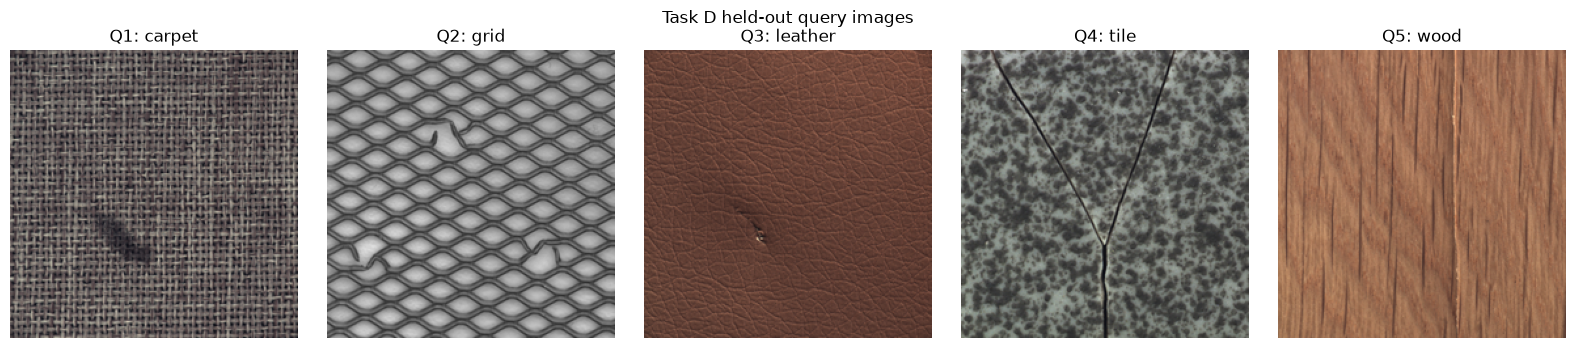

In [8]:
import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from texturelab.supplied import load_image

MANIFEST_DIR = ROOT / "manifests"

with (MANIFEST_DIR / "task_d_queries.csv").open(newline="", encoding="utf8") as handle:
    queries = list(csv.DictReader(handle))

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
for ax, query in zip(axes, queries):
    path = (MANIFEST_DIR / query["path"]).resolve()
    ax.imshow(load_image(str(path), (220, 220)))
    ax.set_title(f"{query['id']}: {query['material']}")
    ax.axis("off")
fig.suptitle("Task D held-out query images")
fig.tight_layout()
plt.show()

## 2. D1 — generic zero-shot

Attach one query image and use only a generic prompt. Ask for a binary defect
decision, a short defect name if abnormal, confidence from 0 to 100, and one
sentence of visible evidence. Do not mention the material or allowed labels.

Suggested prompt:

> Inspect this surface image. Is anything visibly abnormal? Return JSON with
> `is_defective`, `defect_name`, `confidence`, and `evidence`.


Used prompt : Inspect this surface image. Is anything visibly abnormal? 
Return only valid JSON withis_defective, defect_name, confidence, and evidence.

Model : GPT-5.6-sol

D1 - Results : 


Q1
{"is_defective":true,"defect_name":"localized weave distortion/damaged fibers","confidence":0.98,"evidence":"A clearly visible abnormal dark, irregular patch appears in the lower-left/center region, where the otherwise regular woven pattern is disrupted and fibers appear bunched, displaced, or damaged."}

Q2
{"is_defective":true,"defect_name":"broken mesh strands","confidence":0.99,"evidence":"Multiple clear discontinuities are visible in the repeating mesh pattern, with several strands broken, bent, and displaced around the upper-center, lower-left, and lower-right regions."}

Q3
{"is_defective":true,"defect_name":"puncture/tear","confidence":0.99,"evidence":"A distinct small puncture with a short tear and raised/damaged material is visible slightly left of center, disrupting the otherwise consistent textured surface."}

Q4 
{"is_defective":true,"defect_name":"crack","confidence":0.99,"evidence":"A prominent Y-shaped dark crack is visible through the center of the surface, with three distinct branches disrupting the surrounding material."}

Q5
{"is_defective":true,"defect_name":"split/crack","confidence":0.98,"evidence":"A prominent vertical separation runs nearly the full height slightly right of center, forming an irregular open split that is distinct from the surrounding wood grain."}


## 3. D2 — named-defect zero-shot

Provide the material and its allowed defect names with the supplied short
definitions, but no labelled example images. Require exactly one allowed label
or `good`.


In [9]:
prompt = """
Inspect this surface image and find if there is among the following :
{definition}
Only consider a SINGLE label otherwise set defect name to "good".
Return only valid JSON with is_defective, defect_name, confidence, and evidence.
"""

In [10]:
import json

PROMPT_TEMPLATE = """
Inspect this surface image and find if there is among the following :
{definition}
Only consider a SINGLE label otherwise set defect name to "good".
Return only valid JSON with is_defective, defect_name, confidence, and evidence.
"""

definitions = json.loads(
    (MANIFEST_DIR / "task_d_definitions.json").read_text(encoding="utf8")
)
prompts = []
for query in queries:
    defs = definitions[query["material"]]
    definition = "\n".join(f"- {name}: {d}" for name, d in defs.items())
    prompts.append(PROMPT_TEMPLATE.format(definition=definition))
    print(f"{query['id']} — {query['material']}")
    print(prompts[-1])

Q1 — carpet

Inspect this surface image and find if there is among the following :
- color: A localized region has an abnormal colour or tone.
- cut: A sharp incision or sliced region interrupts the texture.
- hole: Material is missing in a compact hole-like region.
- metal_contamination: A metallic foreign object lies on the surface.
- thread: A foreign thread lies across the regular texture.
Only consider a SINGLE label otherwise set defect name to "good".
Return only valid JSON with is_defective, defect_name, confidence, and evidence.

Q2 — grid

Inspect this surface image and find if there is among the following :
- bent: The regular grid lines are locally warped or displaced.
- broken: Part of the repeating grid is interrupted or missing.
- glue: A localized glue deposit changes the surface appearance.
- metal_contamination: A metallic foreign object lies on the surface.
- thread: A foreign thread lies across the regular texture.
Only consider a SINGLE label otherwise set defect n

### D2 - Results
Carpet 
{"is_defective":true,"defect_name":"color","confidence":0.96,"evidence":"A localized dark discolored region is visible slightly left of center in the lower-middle portion of the woven surface."}

Grid
{"is_defective":true,"defect_name":"broken","confidence":0.99,"evidence":"Multiple grid strands are visibly interrupted with separated, free-ended segments, especially in the upper-middle, lower-left, and lower-right regions."}

Leather
{"is_defective":true,"defect_name":"poke","confidence":0.97,"evidence":"A small puncture-like opening with localized material disruption is visible slightly left of center."}

Tile
{"is_defective":true,"defect_name":"crack","confidence":0.99,"evidence":"A prominent narrow dark fracture branches from the lower center into two diagonal lines extending toward the upper edges."}

Wood
{"is_defective":true,"defect_name":"scratch","confidence":0.98,"evidence":"A prominent thin vertical abrasion interrupts the wood surface slightly right of center, with exposed lighter material along its edges."}



## 4. D3 — example-conditioned

Provide the same D2 text plus the fixed support images associated with the
query ID in `task_d_support.csv`. Each support image is labelled and comes only
from public validation. Do not add hand-selected examples or test images.

Ask the VLM to compare the query with all examples and return the same JSON
schema used in D1 and D2.


In [11]:
PROMPT_ADDITION = "One of the attached image provides examples for each type of defect, use it to establish the defect type.\n"
prompts_D3 = [p + PROMPT_ADDITION for p in prompts]

In [12]:
for prompt, query in zip(prompts_D3,queries):

    print(f"{query['id']} — {query['material']}")
    print(prompt)

Q1 — carpet

Inspect this surface image and find if there is among the following :
- color: A localized region has an abnormal colour or tone.
- cut: A sharp incision or sliced region interrupts the texture.
- hole: Material is missing in a compact hole-like region.
- metal_contamination: A metallic foreign object lies on the surface.
- thread: A foreign thread lies across the regular texture.
Only consider a SINGLE label otherwise set defect name to "good".
Return only valid JSON with is_defective, defect_name, confidence, and evidence.
One of the attached image provides examples for each type of defect, use it to establish the defect type.

Q2 — grid

Inspect this surface image and find if there is among the following :
- bent: The regular grid lines are locally warped or displaced.
- broken: Part of the repeating grid is interrupted or missing.
- glue: A localized glue deposit changes the surface appearance.
- metal_contamination: A metallic foreign object lies on the surface.
- thr

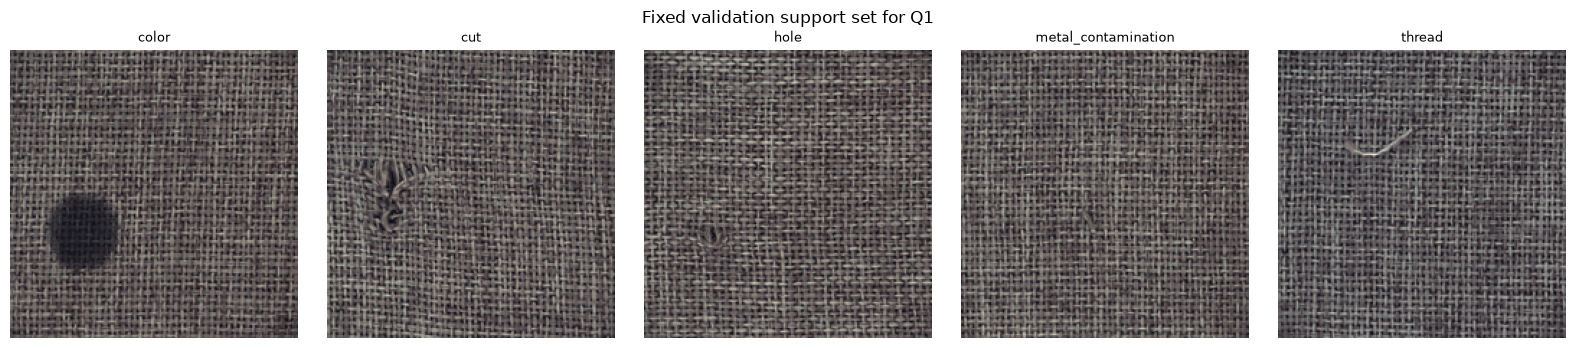

In [13]:
with (MANIFEST_DIR / "task_d_support.csv").open(newline="", encoding="utf8") as handle:
    support = list(csv.DictReader(handle))

# Visualise the fixed support set for the first query.
query_id = queries[0]["id"]
examples = [row for row in support if row["query_id"] == query_id]
fig, axes = plt.subplots(1, len(examples), figsize=(16, 3.5))
for ax, example in zip(axes, examples):
    path = (MANIFEST_DIR / example["path"]).resolve()
    ax.imshow(load_image(str(path), (200, 200)))
    ax.set_title(example["defect_name"], fontsize=9)
    ax.axis("off")
fig.suptitle(f"Fixed validation support set for {query_id}")
fig.tight_layout()
plt.show()

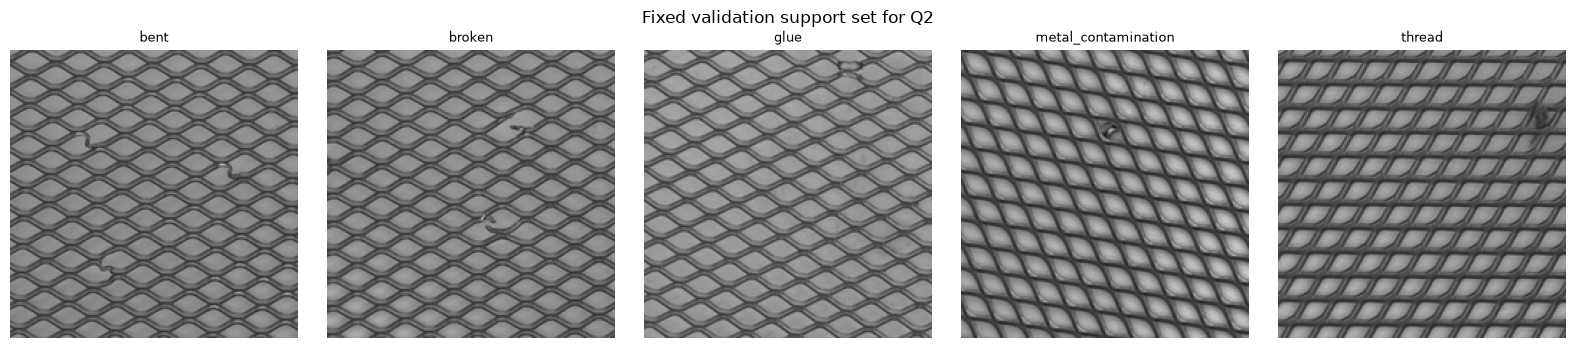

In [14]:
# Visualise the fixed support set for the first query.
query_id = queries[1]["id"]
examples = [row for row in support if row["query_id"] == query_id]
fig, axes = plt.subplots(1, len(examples), figsize=(16, 3.5))
for ax, example in zip(axes, examples):
    path = (MANIFEST_DIR / example["path"]).resolve()
    ax.imshow(load_image(str(path), (200, 200)))
    ax.set_title(example["defect_name"], fontsize=9)
    ax.axis("off")
fig.suptitle(f"Fixed validation support set for {query_id}")
fig.tight_layout()
plt.show()

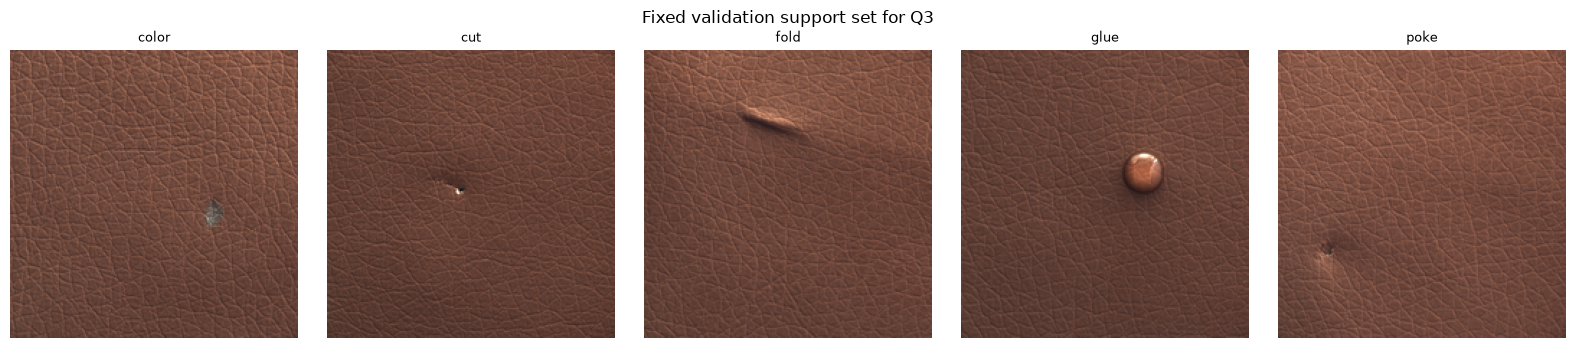

In [15]:
# Visualise the fixed support set for the first query.
query_id = queries[2]["id"]
examples = [row for row in support if row["query_id"] == query_id]
fig, axes = plt.subplots(1, len(examples), figsize=(16, 3.5))
for ax, example in zip(axes, examples):
    path = (MANIFEST_DIR / example["path"]).resolve()
    ax.imshow(load_image(str(path), (200, 200)))
    ax.set_title(example["defect_name"], fontsize=9)
    ax.axis("off")
fig.suptitle(f"Fixed validation support set for {query_id}")
fig.tight_layout()
plt.show()

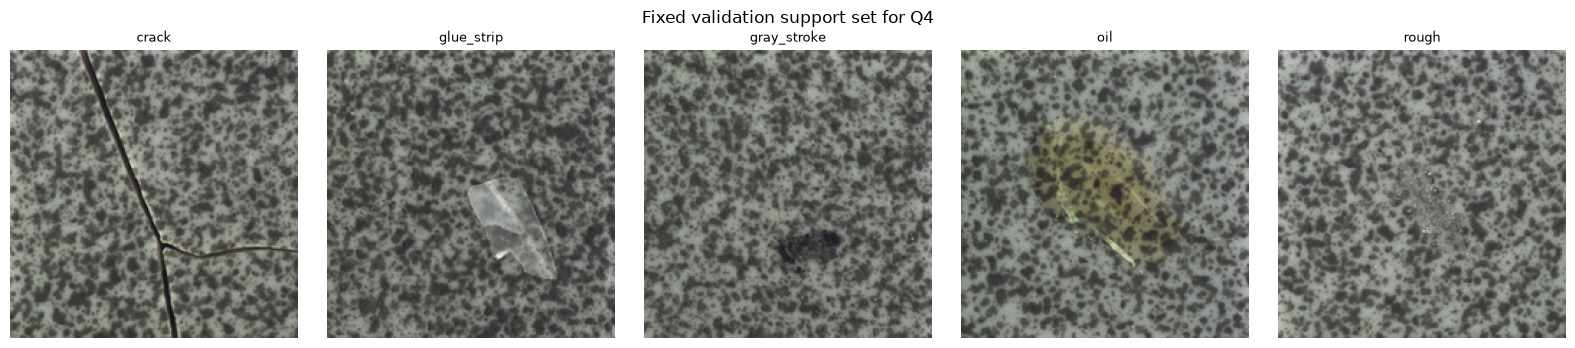

In [16]:
# Visualise the fixed support set for the first query.
query_id = queries[3]["id"]
examples = [row for row in support if row["query_id"] == query_id]
fig, axes = plt.subplots(1, len(examples), figsize=(16, 3.5))
for ax, example in zip(axes, examples):
    path = (MANIFEST_DIR / example["path"]).resolve()
    ax.imshow(load_image(str(path), (200, 200)))
    ax.set_title(example["defect_name"], fontsize=9)
    ax.axis("off")
fig.suptitle(f"Fixed validation support set for {query_id}")
fig.tight_layout()
plt.show()

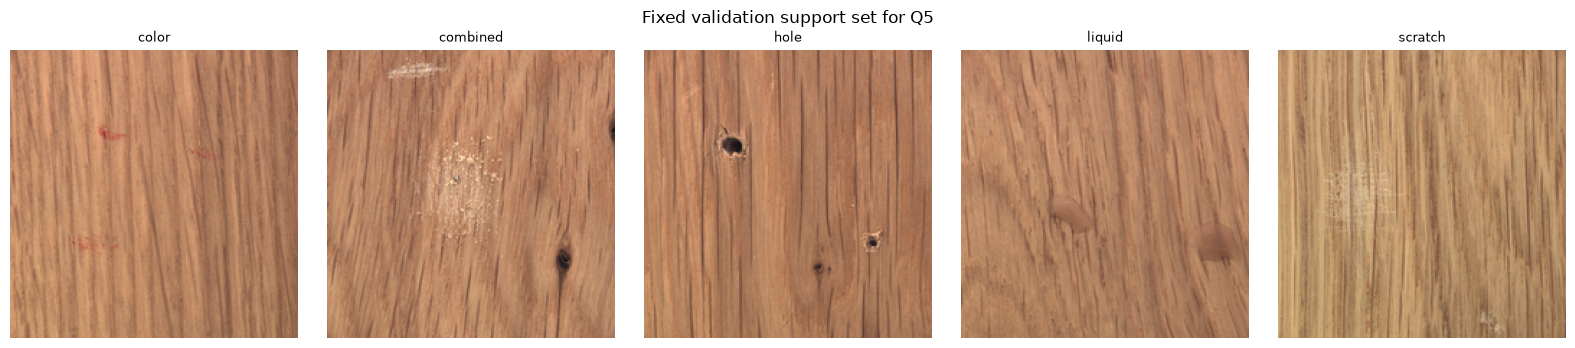

In [17]:
# Visualise the fixed support set for the first query.
query_id = queries[4]["id"]
examples = [row for row in support if row["query_id"] == query_id]
fig, axes = plt.subplots(1, len(examples), figsize=(16, 3.5))
for ax, example in zip(axes, examples):
    path = (MANIFEST_DIR / example["path"]).resolve()
    ax.imshow(load_image(str(path), (200, 200)))
    ax.set_title(example["defect_name"], fontsize=9)
    ax.axis("off")
fig.suptitle(f"Fixed validation support set for {query_id}")
fig.tight_layout()
plt.show()

### D3 - Results

Q1
{"is_defective":true,"defect_name":"color","confidence":0.96,"evidence":"A localized dark-toned patch is visible in the lower-left/central region while the woven texture remains structurally intact, closely matching the provided color-defect example."}

Q2 
{"is_defective":true,"defect_name":"broken","confidence":0.98,"evidence":"Several grid strands are visibly interrupted with separated, free-ended segments, closely matching the provided broken-defect example."}

Q3
{"is_defective":true,"defect_name":"cut","confidence":0.96,"evidence":"A sharp elongated incision with a small opened/damaged endpoint interrupts the leather texture near the lower-left central region, closely matching the provided cut example."}

Q4
{"is_defective":true,"defect_name":"crack","confidence":0.99,"evidence":"Multiple narrow dark fracture-like lines converge near the center and extend across the material surface, closely matching the provided crack example."}

Q5
{"is_defective":false,"defect_name":"good","confidence":0.97,"evidence":"The surface shows normal longitudinal wood grain and a natural seam-like boundary, with no localized abnormal color, compact hole, liquid stain, thin abrasion, or combination of the provided defect types."}

## 5. Record predictions before scoring

Create one row per query and condition with: query ID, condition, predicted
label, defective/not-defective decision, confidence, visible evidence, exact
prompt, model/version, and run date. Preserve the raw conversations or exported
screenshots as evidence. Only after all 15 responses are frozen should the
answer key be used to calculate accuracy.


In [18]:
# [AI-CODE]
import csv
import json

MODEL_VERSION = "GPT-5.6-sol"
RUN_DATE = "2026-10-04"  

D1_PROMPT = (
    "Inspect this surface image. Is anything visibly abnormal? \n"
    "Return only valid JSON withis_defective, defect_name, confidence, and evidence."
)

# Raw VLM outputs, in query order (Q1..Q5), copied verbatim from the cells above.
raw_responses = {
    "D1": [
        '{"is_defective":true,"defect_name":"localized weave distortion/damaged fibers","confidence":0.98,"evidence":"A clearly visible abnormal dark, irregular patch appears in the lower-left/center region, where the otherwise regular woven pattern is disrupted and fibers appear bunched, displaced, or damaged."}',
        '{"is_defective":true,"defect_name":"broken mesh strands","confidence":0.99,"evidence":"Multiple clear discontinuities are visible in the repeating mesh pattern, with several strands broken, bent, and displaced around the upper-center, lower-left, and lower-right regions."}',
        '{"is_defective":true,"defect_name":"puncture/tear","confidence":0.99,"evidence":"A distinct small puncture with a short tear and raised/damaged material is visible slightly left of center, disrupting the otherwise consistent textured surface."}',
        '{"is_defective":true,"defect_name":"crack","confidence":0.99,"evidence":"A prominent Y-shaped dark crack is visible through the center of the surface, with three distinct branches disrupting the surrounding material."}',
        '{"is_defective":true,"defect_name":"split/crack","confidence":0.98,"evidence":"A prominent vertical separation runs nearly the full height slightly right of center, forming an irregular open split that is distinct from the surrounding wood grain."}',
    ],
    "D2": [
        '{"is_defective":true,"defect_name":"color","confidence":0.96,"evidence":"A localized dark discolored region is visible slightly left of center in the lower-middle portion of the woven surface."}',
        '{"is_defective":true,"defect_name":"broken","confidence":0.99,"evidence":"Multiple grid strands are visibly interrupted with separated, free-ended segments, especially in the upper-middle, lower-left, and lower-right regions."}',
        '{"is_defective":true,"defect_name":"poke","confidence":0.97,"evidence":"A small puncture-like opening with localized material disruption is visible slightly left of center."}',
        '{"is_defective":true,"defect_name":"crack","confidence":0.99,"evidence":"A prominent narrow dark fracture branches from the lower center into two diagonal lines extending toward the upper edges."}',
        '{"is_defective":true,"defect_name":"scratch","confidence":0.98,"evidence":"A prominent thin vertical abrasion interrupts the wood surface slightly right of center, with exposed lighter material along its edges."}',
    ],
    "D3": [
        '{"is_defective":true,"defect_name":"color","confidence":0.96,"evidence":"A localized dark-toned patch is visible in the lower-left/central region while the woven texture remains structurally intact, closely matching the provided color-defect example."}',
        '{"is_defective":true,"defect_name":"broken","confidence":0.98,"evidence":"Several grid strands are visibly interrupted with separated, free-ended segments, closely matching the provided broken-defect example."}',
        '{"is_defective":true,"defect_name":"cut","confidence":0.96,"evidence":"A sharp elongated incision with a small opened/damaged endpoint interrupts the leather texture near the lower-left central region, closely matching the provided cut example."}',
        '{"is_defective":true,"defect_name":"crack","confidence":0.99,"evidence":"Multiple narrow dark fracture-like lines converge near the center and extend across the material surface, closely matching the provided crack example."}',
        '{"is_defective":false,"defect_name":"good","confidence":0.97,"evidence":"The surface shows normal longitudinal wood grain and a natural seam-like boundary, with no localized abnormal color, compact hole, liquid stain, thin abrasion, or combination of the provided defect types."}',
    ],
}

condition_prompts = {
    "D1": [D1_PROMPT] * len(queries),
    "D2": prompts,
    "D3": prompts_D3,
}

allowed = {q["id"]: set(q["allowed_defects"].split(";")) | {"good"} for q in queries}

predictions = []
for condition, responses in raw_responses.items():
    for query, prompt, raw in zip(queries, condition_prompts[condition], responses):
        parsed = json.loads(raw) if raw else {}
        label = parsed.get("defect_name")
        predictions.append({
            "query_id": query["id"],
            "material": query["material"],
            "condition": condition,
            "predicted_label": label,
            "is_defective": parsed.get("is_defective"),
            "confidence": parsed.get("confidence"),
            "evidence": parsed.get("evidence"),
            # D1 has no allowed vocabulary, so the check only applies to D2/D3.
            "in_vocabulary": None if condition == "D1" or label is None else label in allowed[query["id"]],
            "prompt": prompt.strip(),
            "model_version": MODEL_VERSION,
            "run_date": RUN_DATE,
            "raw_response": raw,
        })

OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
with (OUT_DIR / "task_d_predictions.csv").open("w", newline="", encoding="utf8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(predictions[0]))
    writer.writeheader()
    writer.writerows(predictions)

# Compact summary (prompts, evidence and raw responses are in the CSV).
print(f"{'query':<6}{'cond':<6}{'defective':<11}{'conf':<6}{'in_vocab':<10}predicted_label")
for row in predictions:
    print(f"{row['query_id']:<6}{row['condition']:<6}{str(row['is_defective']):<11}"
          f"{str(row['confidence']):<6}{str(row['in_vocabulary']):<10}{row['predicted_label']}")


query cond  defective  conf  in_vocab  predicted_label
Q1    D1    True       0.98  None      localized weave distortion/damaged fibers
Q2    D1    True       0.99  None      broken mesh strands
Q3    D1    True       0.99  None      puncture/tear
Q4    D1    True       0.99  None      crack
Q5    D1    True       0.98  None      split/crack
Q1    D2    True       0.96  True      color
Q2    D2    True       0.99  True      broken
Q3    D2    True       0.97  True      poke
Q4    D2    True       0.99  True      crack
Q5    D2    True       0.98  True      scratch
Q1    D3    True       0.96  True      color
Q2    D3    True       0.98  True      broken
Q3    D3    True       0.96  True      cut
Q4    D3    True       0.99  True      crack
Q5    D3    False      0.97  True      good


## Analysis ideas

- Compare D1 anomaly discovery with D2/D3 exact-label accuracy.
- Count answers that violate the allowed vocabulary.
- Plot confidence for correct and incorrect predictions by condition.
- Identify queries where definitions help but examples do not, and vice versa.
- Discuss prompt sensitivity, model updates, nondeterminism, and possible prior
  exposure to the public MVTec dataset.
- Do not claim that five images establish general VLM superiority; this is a
  controlled qualitative probe.


In [19]:
# - Plot confidence for correct and incorrect predictions by condition.

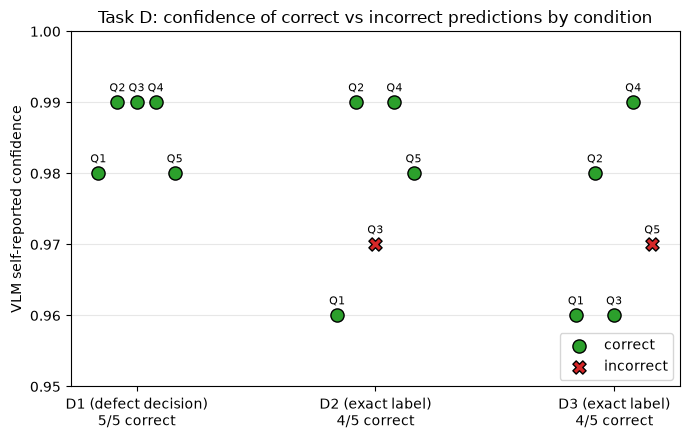

In [20]:
# [AI-CODE]
import csv

import matplotlib.pyplot as plt

# Answer key is only opened here, after all 15 responses were frozen above.
with (ROOT / "solution" / "task_d_answer_key.csv").open(newline="", encoding="utf8") as handle:
    true_labels = {row["id"]: row["true_defect"] for row in csv.DictReader(handle)}

# D1 uses free-form vocabulary, so it is scored on the defect decision only.
# D2/D3 must name an allowed label, so they are scored on exact label match.
for row in predictions:
    true_label = true_labels[row["query_id"]]
    if row["condition"] == "D1":
        row["correct"] = row["is_defective"] == (true_label != "good")
    else:
        row["correct"] = row["predicted_label"] == true_label

conditions = ["D1", "D2", "D3"]
fig, ax = plt.subplots(figsize=(7, 4.5))
for correct, colour, marker, name in [(True, "tab:green", "o", "correct"), (False, "tab:red", "X", "incorrect")]:
    xs, ys = [], []
    for row in predictions:
        if row["correct"] == correct:
            # Small horizontal offset per query so overlapping points stay visible.
            xs.append(conditions.index(row["condition"]) + (int(row["query_id"][1:]) - 3) * 0.08)
            ys.append(row["confidence"])
    ax.scatter(xs, ys, c=colour, marker=marker, s=90, label=name, edgecolors="black", zorder=3)

for row in predictions:
    x = conditions.index(row["condition"]) + (int(row["query_id"][1:]) - 3) * 0.08
    ax.annotate(row["query_id"], (x, row["confidence"]), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8)

scoring = {"D1": "defect decision", "D2": "exact label", "D3": "exact label"}
tick_labels = []
for cond in conditions:
    n_correct = sum(r["correct"] for r in predictions if r["condition"] == cond)
    tick_labels.append(f"{cond} ({scoring[cond]})\n{n_correct}/5 correct")

ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(tick_labels)
ax.set_ylim(0.95, 1.0)
ax.set_ylabel("VLM self-reported confidence")
ax.set_title("Task D: confidence of correct vs incorrect predictions by condition")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()
